# Predicting Penguin Species Using Antarctica Survey Data
----------------------------------------------------------------

# Welcome to Antarctica.
Alright, let’s talk about penguins.

# The problem we are solving
Can we predict which species of penguin we are observing based on survey characteristics?

As you can see in the data, different species have different preferences: some prefer certain latitudes, some form massive colonies while others do not — which you will see in the EDA.


Let’s import the required libraries first. Then we’ll explore the dataset features.


# Part1:
- Importing our tools.

In [10]:
# Importing Required Libraries

# Numerical and data handling
import numpy as np          # For numerical operations
import pandas as pd         # For data manipulation and analysis

# Visualization
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Advanced statistical plots

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Model selection and validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [16]:
df = pd.read_csv('Downloads/AllCounts_V_4_4.csv')
print('Data Overview')
print('='*70)
print(df.head())
print(df.info())
print(df.shape)

Data Overview
      site_name site_id cammlr_region  longitude_epsg_4326  \
0  Acuna Island    ACUN          48.2              -44.637   
1  Acuna Island    ACUN          48.2              -44.637   
2  Acuna Island    ACUN          48.2              -44.637   
3  Acuna Island    ACUN          48.2              -44.637   
4  Acuna Island    ACUN          48.2              -44.637   

   latitude_epsg_4326        common_name   day  month  year  season_starting  \
0             -60.761     adelie penguin   NaN    NaN  1993             1993   
1             -60.761     adelie penguin   NaN    NaN  1994             1994   
2             -60.761     adelie penguin   NaN    NaN  2004             2004   
3             -60.761     adelie penguin  25.0    2.0  2011             2010   
4             -60.761  chinstrap penguin  28.0   12.0  1983             1983   

   penguin_count  accuracy count_type vantage  \
0         2008.0       1.0      nests  ground   
1         1920.0       1.0      ne

# Data Overview
 ===============================

 Total records: 5407
 Total features: 15

 **Dataset contains:**
- Location details (site_name, site_id, region, latitude, longitude)
- Species information (common_name)
- Date-related features (day, month, year, season_starting)
- Survey details (penguin_count, accuracy, count_type, vantage)
- Reference/source information

**Observations:**
 1. No missing values in location and species columns.
 2. 'day' and 'month' have many missing values.
 3. 'penguin_count' and 'accuracy' have a few missing values.
 4. 'vantage' has some missing values.
 5. Mixture of numerical (float, int) and categorical (object) features.

 **Target variable:**
 common_name → Penguin species

- Shape of dataset:
 (5407 rows, 15 columns)

**I hope you r getting my points.**

In [25]:
# Lets take a look on data.
df.head()

,site_name,site_id,cammlr_region,longitude_epsg_4326,latitude_epsg_4326,common_name,day,month,year,season_starting,penguin_count,accuracy,count_type,vantage,reference
0,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1993,1993,2008.0,1.0,nests,ground,"<p id=""coria2011laurie"" class=""reference"">Cori..."
1,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,1994,1994,1920.0,1.0,nests,NaN,"<p id=""woehler1997status"" class=""reference"">Wo..."
2,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,NaN,NaN,2004,2004,1880.0,1.0,nests,ground,"<p id=""coria2011laurie"" class=""reference"">Cori..."
3,Acuna Island,ACUN,48.2,-44.637,-60.761,adelie penguin,25.0,2.0,2011,2010,3079.0,5.0,nests,vhr,"<p id=""lynch2014global"" class=""reference"">Lync..."
4,Acuna Island,ACUN,48.2,-44.637,-60.761,chinstrap penguin,28.0,12.0,1983,1983,4000.0,4.0,nests,ground,"<p id=""poncet1985survey"" class=""reference"">Pon..."


- The 'reference' column contains HTML-formatted citation data, it is not useful for prediction so we will drop this column during preprocessing.


# Part 2: Exploratory Data Analysis (EDA)
 - Time to understand the penguin data in detail.
 - **Note**='common_name' represents the species of penguin (target variable).

In [75]:
# Penguin Species Distribution.
print("PENGUIN SPECIES DISTRIBUTION")
print("="*50)
species_count = df['common_name'].value_counts(normalize=True)*100
species_percent = species_count.round(2).astype(str) + '%'
print(species_percent)
print(f"\nTotal surveys: {len(df):,}")

PENGUIN SPECIES DISTRIBUTION
common_name
adelie penguin       34.58%
gentoo penguin       29.04%
chinstrap penguin    27.74%
emperor penguin        6.1%
macaroni penguin      2.29%
king penguin          0.24%
Name: proportion, dtype: object

Total surveys: 5,407


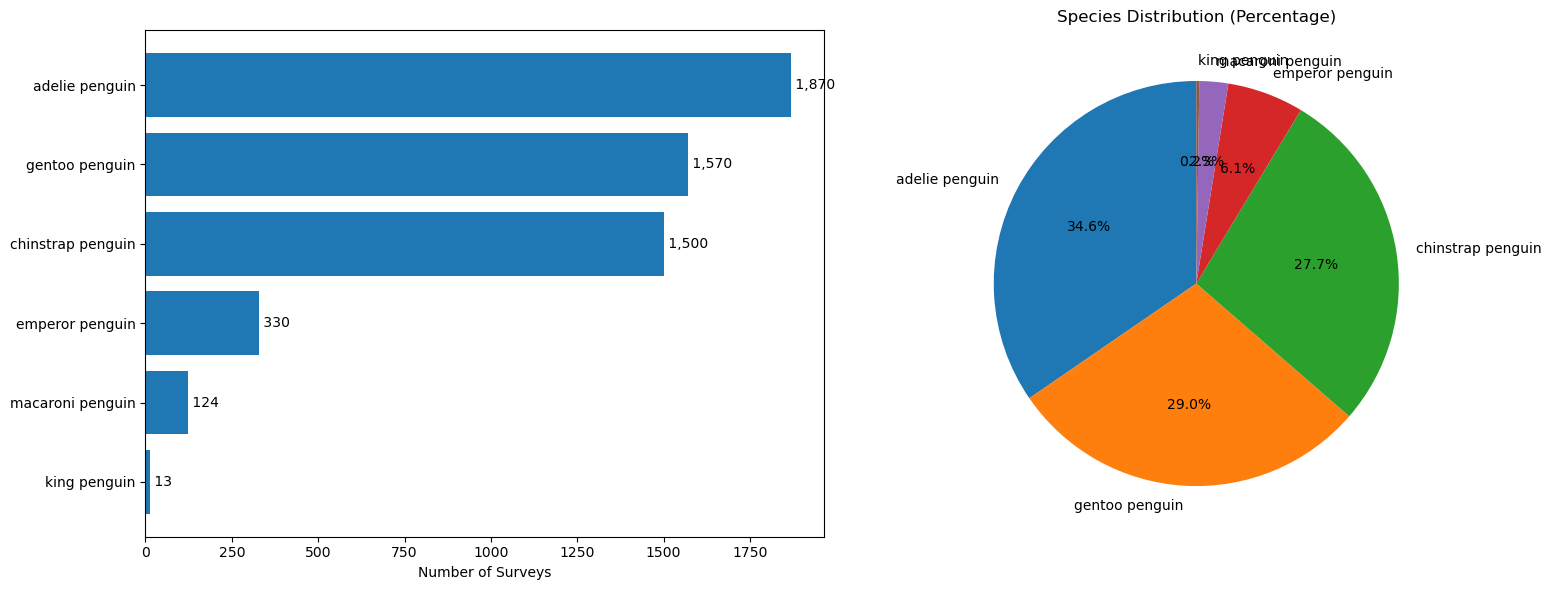

<Figure size 640x480 with 0 Axes>

In [97]:
# Counts
species_counts = df['common_name'].value_counts()

# Numeric percentage 
species_percent = df['common_name'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bar Plot 
ax[0].barh(species_counts.index, species_counts.values)
ax[1].set_title("Survey Count by Penguin Species")
ax[0].set_xlabel("Number of Surveys")
ax[0].invert_yaxis()

for i, v in enumerate(species_counts.values):
    ax[0].text(v, i, f" {v:,}", va='center')

# Pie Chart
ax[1].pie(
    species_percent.values,   # use numeric values
    labels=species_percent.index,
    autopct='%1.1f%%',
    startangle=90
)

ax[1].set_title("Species Distribution (Percentage)")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


# Key Insights

- **Adelie Penguin**  
  Holds the highest count (1870 surveys, 34.6% of total).  
  It clearly dominates the dataset. Adélie penguins are one of the smallest Antarctic species — cute in appearance but known for their aggressive and energetic behavior.

- **Gentoo Penguin**  
  Second highest representation in the data.

- **Chinstrap Penguin**  
  Third most observed species in the dataset.

- **Emperor, Macaroni, and King Penguins**  
  Combined total = 467 surveys, showing much lower representation compared to the top three species.

# Personal Note
To better understand these species, consider exploring documentaries or reading detailed descriptions on platforms like Wikipedia or educational YouTube channels.


# Did you notice one thing 
- Our data is highly imbalance, Our models will have to handle this.
- Adelie ≈ 34–35%
- Top 3 species dominate most of the data
- Bottom 3 species together are much smaller

In [119]:
# Checking missing value.
missing = df.isnull().sum()
missing_val = (missing/ len(df) * 100).round(2).astype(str) +'%'
print(missing_val)

site_name                0.0%
site_id                  0.0%
cammlr_region            0.0%
longitude_epsg_4326      0.0%
latitude_epsg_4326       0.0%
common_name              0.0%
day                    38.88%
month                  27.83%
year                     0.0%
season_starting          0.0%
penguin_count           0.33%
accuracy                0.33%
count_type               0.0%
vantage                 5.66%
reference                0.0%
dtype: object


In [111]:
# In simple language 
df.isnull().sum()

site_name                 0
site_id                   0
cammlr_region             0
longitude_epsg_4326       0
latitude_epsg_4326        0
common_name               0
day                    2102
month                  1505
year                      0
season_starting           0
penguin_count            18
accuracy                 18
count_type                0
vantage                 306
reference                 0
dtype: int64

- No missing values in most core columns (site info, species, year, region).
- 'day' → 38.88% missing (high missing rate).
- 'month' → 27.83% missing (moderate missing rate).
- 'vantage' → 5.66% missing.
- 'penguin_count' and 'accuracy' → 0.33% missing (very small).
- 'reference' → 0% missing but not useful for modeling.

# Observation
Date-related columns (day, month) have significant missing values and may need:
- Imputation  
- Feature engineering  
- Or removal (depending on importance)


In [129]:
df.duplicated().sum()

0

- Duplicate value = A row that appears more than once in dataset.
- No duplicates found.

In [149]:
# Numerical Feature Analysis.
numerical_cols = ['longitude_epsg_4326', 'latitude_epsg_4326', 'year',
                  'season_starting', 'penguin_count', 'accuracy']

display(df[numerical_cols].describe().round(2))

,longitude_epsg_4326,latitude_epsg_4326,year,season_starting,penguin_count,accuracy
count,5407.00,5407.00,5407.00,5407.00,5389.00,5389.00
mean,-14.34,-65.74,2002.43,2002.08,7092.62,1.72
std,85.28,4.42,15.86,15.78,25932.39,1.20
min,-157.70,-77.71,1892.00,1892.00,0.00,1.00
25%,-62.67,-66.67,1990.00,1990.00,212.00,1.00
50%,-58.93,-64.76,2007.00,2007.00,1000.00,1.00
75%,-38.99,-62.46,2014.00,2014.00,3440.00,2.00
max,171.17,-60.55,2025.00,2024.00,504332.00,5.00


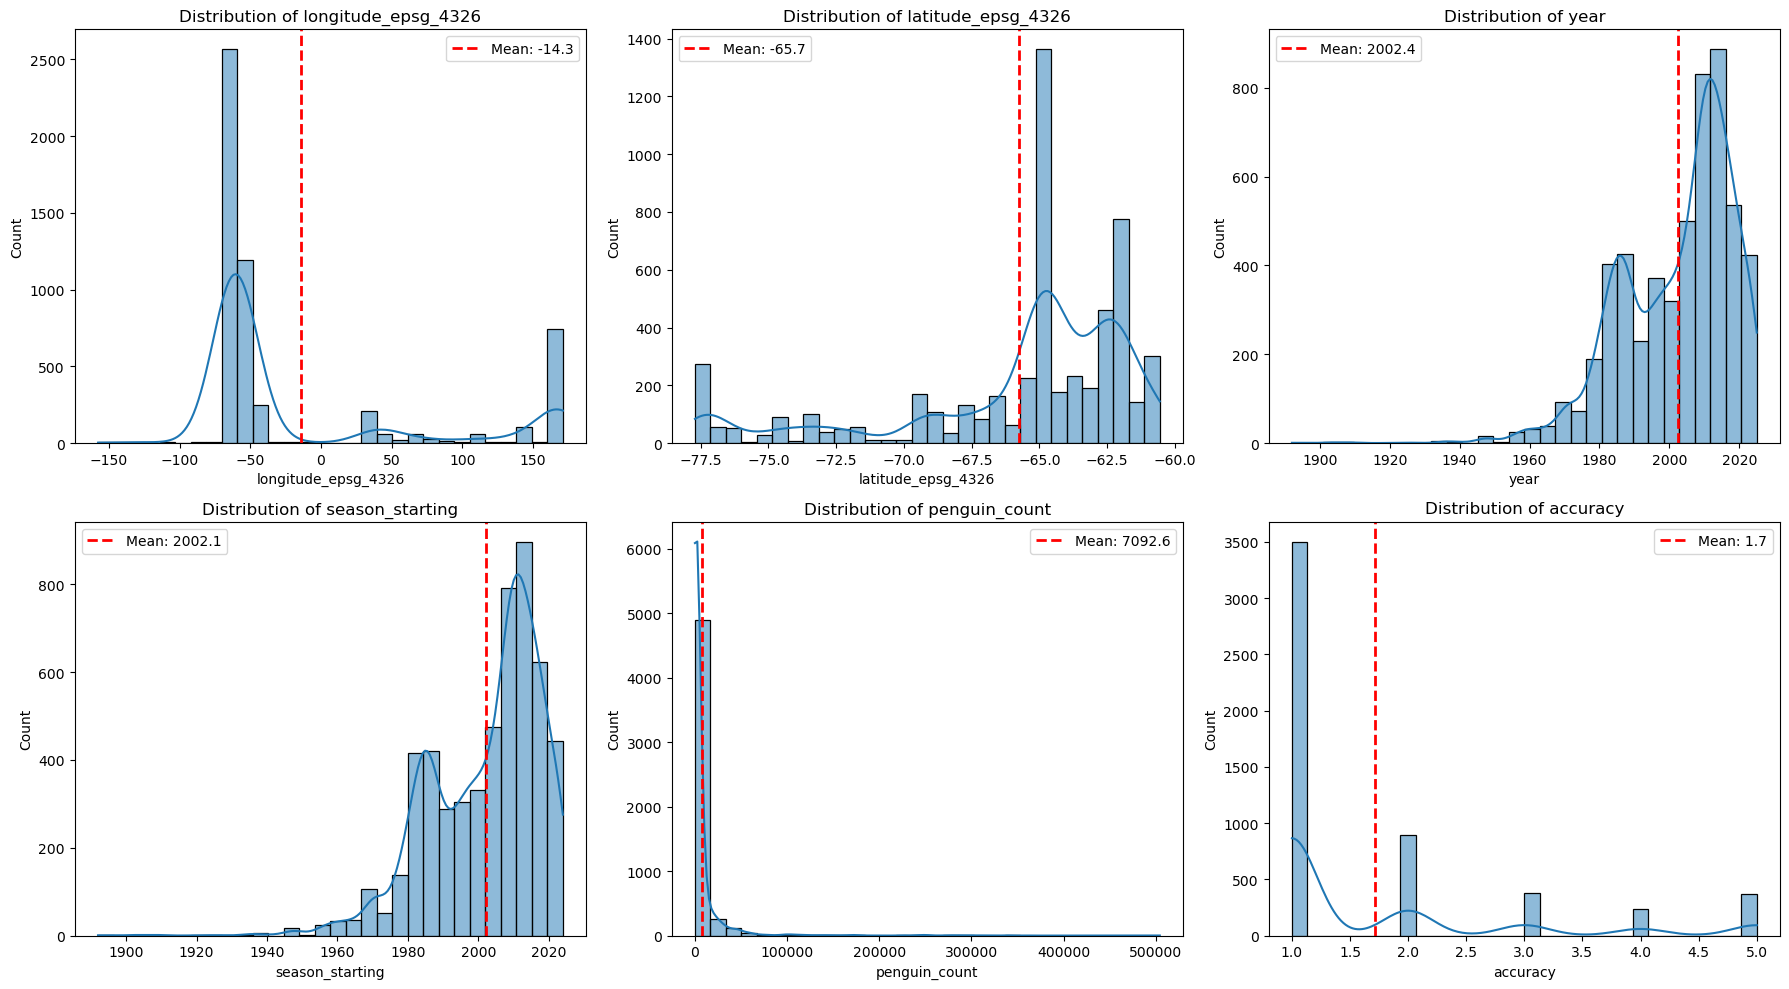

In [151]:
numerical_cols = ['longitude_epsg_4326', 'latitude_epsg_4326', 'year',
                  'season_starting', 'penguin_count', 'accuracy']

plt.figure(figsize=(18, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    
    # Histogram + KDE
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    
    # Mean line
    mean_val = df[col].mean()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f"Mean: {mean_val:.1f}")
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()

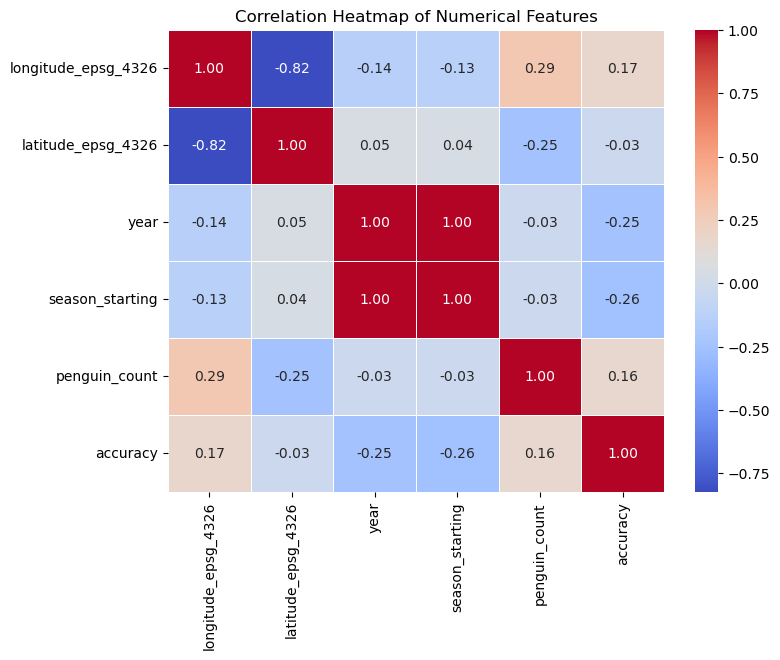

In [169]:
# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,          # show numbers
            fmt=".2f",           # 2 decimal places
            cmap="coolwarm",     # color theme
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()


- Here we r checking how much numerical features are related to each other.
- **Key Insights:**
year and season_starting show perfect correlation (1.00) → they contain redundant information. One of them can be removed.

longitude and latitude have a strong negative correlation (-0.82) → indicates strong geographic structure in colony locations.

penguin_count has weak correlation with other variables → colony size is not strongly dependent on time or accuracy.

accuracy shows slight negative correlation with year → suggests possible changes in data collection methods over time.

Overall, no severe multicollinearity except between year and season_starting.

# Finally let's prepare  data for modeling.

In [178]:
# Make a copy
model_df = df.copy()

# Select features
feature_cols = ['longitude_epsg_4326', 'latitude_epsg_4326', 'year',
                'penguin_count', 'accuracy', 'count_type', 'vantage']
target_col = 'common_name'

# Handle missing values
model_df['vantage'] = model_df['vantage'].fillna('unknown')
model_df = model_df.dropna(subset=feature_cols)

# Log transform penguin_count (to reduce skewness)
import numpy as np
model_df['penguin_count'] = np.log1p(model_df['penguin_count'])

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

for col in ['count_type', 'vantage', target_col]:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])

# Final datasets
X = model_df[feature_cols]
y = model_df[target_col]


- Created a copy of the original dataset to preserve raw data.

- Selected relevant numerical and categorical features for modeling.

- Filled missing values in vantage with "unknown" and removed remaining rows with missing feature values.

- Applied log transformation to penguin_count to reduce skewness and handle extreme values.

- Encoded categorical variables (count_type, vantage, and target common_name) using Label Encoding.

- Prepared final feature matrix X and target variable y for model training.

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [188]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}
results = {}

# Train and evaluating each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Showing best model
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])


Logistic Regression: 0.6234
Random Forest: 0.9212
Decision Tree: 0.9091
KNN: 0.7737
SVM: 0.4954
Naive Bayes: 0.6122

Best Model: Random Forest
Best Accuracy: 0.9211502782931354


In [190]:
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
1,Random Forest,0.921150
2,Decision Tree,0.909091
3,KNN,0.773655
0,Logistic Regression,0.623377
5,Naive Bayes,0.612245
4,SVM,0.495362


We took a virtual trip to Antarctica, counted penguins, and uncovered something fascinating: species can be predicted surprisingly well using only survey metadata.

Location turned out to be the key. Geographic coordinates carry powerful signals because each species occupies distinct ecological territories shaped by millions of years of evolution.

Adélies are widespread and adaptable. Chinstraps cluster around the Antarctic Peninsula. Emperors dominate the deep southern regions. Gentoos favor comparatively milder northern zones.

Our best-performing model successfully captured these spatial patterns and achieved strong classification accuracy. It’s not flawless — overlapping habitats create ambiguity between certain species — but it’s reliable enough to support quality control and ecological monitoring efforts.

What this analysis doesn’t answer are the deeper ecological questions:
Why are populations increasing or declining? How is climate change influencing distributions? What drives their feeding behavior?

Those are complex challenges — and opportunities — for future exploration.

Until then: keep your models tuned, your assumptions tested, and your data clean.